Small notebook for comparison of paleorca and orca runs

In [25]:
import xarray as xr
from cdo import Cdo
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
cdo = Cdo()

PATH = "/lus/h2resw01/scratch/ccpd/ece4"
# load NEMO output for a given experiment, with options to load only the last n years, regrid to a common grid, and handle running simulations
def load_nemo(expname, last_n_years=None, grid='T', regrid=False, running=False):
    nemofiles = sorted(glob(f"{PATH}/{expname}/output/nemo/{expname}_oce_1m_{grid}_*.nc"))
    print(f"Found {len(nemofiles)} files for experiment {expname}")
    if running:
        print("Simulation is running, removing the last file to avoid loading incomplete data.")
        nemofiles = nemofiles[:-1]
    if last_n_years is not None:
        if last_n_years >= len(nemofiles):
            raise ValueError(f"Requested last {last_n_years} years, but only {len(nemofiles)} files are available.")
        if last_n_years > 0:
            nemofiles = (nemofiles)[-last_n_years:]
    print(f"Loading following files: {nemofiles}")
    if regrid and last_n_years != 1:
        raise ValueError("Regridding is only supported for loading a single year of data.")
    if regrid:
        for f in nemofiles:
            print(f"Regridding {f}...")
            ds = cdo.remapnn("r360x180", input=f, returnXDataset=True)
    else:
        ds = xr.open_mfdataset(nemofiles, combine="by_coords", data_vars='all')
    ds = ds.rename({"time_counter": "time"})

    return ds

# compute area of each grid cell from the domain configuration file
def load_area(expname):
    areafile = f"{PATH}/{expname}/domain_cfg.nc"
    print(f"Loading area file: {areafile}")
    ds = xr.open_dataset(areafile)
    area = (ds['e1t'] * ds['e2t']).squeeze()
    return area

# compute bathymetry of each grid cell from the domain configuration file
def load_bathy(expname):
    bathyfile = f"{PATH}/{expname}/domain_cfg.nc"
    print(f"Loading bathymetry file: {bathyfile}")
    ds = xr.open_dataset(bathyfile)
    bathy = ds['bathy_metry'].squeeze()
    return bathy

In [27]:
paleorca_last = load_nemo("KA02", last_n_years=1, regrid=True)
orca_last = load_nemo("KA03", last_n_years=1, regrid=True)
paleorca_bathy = load_bathy("KA02")
orca_bathy = load_bathy("KA03")


Found 50 files for experiment KA02
Loading following files: ['/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2039-2039.nc']
Regridding /lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2039-2039.nc...
Found 50 files for experiment KA03
Loading following files: ['/lus/h2resw01/scratch/ccpd/ece4/KA03/output/nemo/KA03_oce_1m_T_2039-2039.nc']
Regridding /lus/h2resw01/scratch/ccpd/ece4/KA03/output/nemo/KA03_oce_1m_T_2039-2039.nc...
Loading bathymetry file: /lus/h2resw01/scratch/ccpd/ece4/KA02/domain_cfg.nc
Loading bathymetry file: /lus/h2resw01/scratch/ccpd/ece4/KA03/domain_cfg.nc


mask

In [36]:
import numpy as np
import pandas as pd


def _get_lat_lon_names(obj):
    lat_name = next((name for name in ['nav_lat', 'lat', 'latitude'] if name in obj.coords), None)
    lon_name = next((name for name in ['nav_lon', 'lon', 'longitude'] if name in obj.coords), None)
    if lat_name is None or lon_name is None:
        raise ValueError(f'Could not find lat/lon coordinates in {list(obj.coords)}')
    return lat_name, lon_name


def add_closest_reference_bathymetry(table, reference_bathy, reference_coords, prefix='closest_orca'):
    ref_lat_name, ref_lon_name = _get_lat_lon_names(reference_coords)

    ref_lat = np.asarray(reference_coords[ref_lat_name].values).ravel()
    ref_lon = np.asarray(reference_coords[ref_lon_name].values).ravel()
    ref_bathy = np.asarray(reference_bathy.values).ravel()

    valid = np.isfinite(ref_lat) & np.isfinite(ref_lon) & np.isfinite(ref_bathy)
    ref_lat = ref_lat[valid]
    ref_lon = ref_lon[valid]
    ref_bathy = ref_bathy[valid]

    nearest_lats = []
    nearest_lons = []
    nearest_bathy = []
    nearest_distance_deg = []

    for lat, lon in zip(table['lat'].values, table['lon'].values):
        dist2 = (ref_lat - lat) ** 2 + (ref_lon - lon) ** 2
        nearest_idx = int(np.argmin(dist2))
        nearest_lats.append(ref_lat[nearest_idx])
        nearest_lons.append(ref_lon[nearest_idx])
        nearest_bathy.append(ref_bathy[nearest_idx])
        nearest_distance_deg.append(np.sqrt(dist2[nearest_idx]))

    table = table.copy()
    table[f'{prefix}_lat'] = nearest_lats
    table[f'{prefix}_lon'] = nearest_lons
    table[f'{prefix}_bathymetry_m'] = nearest_bathy
    table[f'{prefix}_distance_deg'] = nearest_distance_deg
    return table


def top_mean_tos_with_bathymetry(ds_last, bathy, expname, n_points=5, var='tos'):
    mean_tos = ds_last[var].mean(dim='time', skipna=True)
    used_native_grid = False

    # The regridded last-year field does not share the native bathymetry grid.
    # If needed, reload the last year on the native grid so bathymetry matches cell-by-cell.
    if tuple(mean_tos.dims) != tuple(bathy.dims):
        ds_last_native = load_nemo(expname, last_n_years=1, regrid=False)
        mean_tos = ds_last_native[var].mean(dim='time', skipna=True)
        used_native_grid = True

    spatial_dims = mean_tos.dims
    summary = xr.Dataset({
        'mean_tos': mean_tos,
        'bathymetry': bathy,
    })

    lat_name, lon_name = _get_lat_lon_names(summary)
    summary['cell_lat'] = summary[lat_name]
    summary['cell_lon'] = summary[lon_name]

    summary = summary.stack(cell=spatial_dims).dropna(dim='cell', subset=['mean_tos'])
    topn = summary.sortby('mean_tos', ascending=False).isel(cell=slice(0, n_points))

    table = pd.DataFrame({
        'rank': range(1, topn.sizes['cell'] + 1),
        'mean_tos': topn['mean_tos'].values,
        'bathymetry_m': topn['bathymetry'].values,
    })

    for dim in spatial_dims:
        table[dim] = topn[dim].values

    table['lat'] = topn['cell_lat'].values
    table['lon'] = topn['cell_lon'].values

    ordered_cols = [
        col for col in ['rank', 'lat', 'lon', *spatial_dims, 'mean_tos', 'bathymetry_m']
        if col in table.columns
    ]
    table = table[ordered_cols]

    return table, used_native_grid


n_points = 10

paleorca_top_tos, paleorca_used_native_grid = top_mean_tos_with_bathymetry(
    paleorca_last,
    paleorca_bathy,
    expname='KA02',
    n_points=n_points,
    var='tos',
)

orca_last_native = load_nemo('KA03', last_n_years=1, regrid=False)
orca_reference_coords = orca_last_native['tos'].mean(dim='time', skipna=True)

paleorca_top_tos = add_closest_reference_bathymetry(
    paleorca_top_tos,
    orca_bathy,
    orca_reference_coords,
    prefix='closest_orca',
)

round_map = {
    key: value for key, value in {
        'lat': 3,
        'lon': 3,
        'mean_tos': 3,
        'bathymetry_m': 1,
        'closest_orca_lat': 3,
        'closest_orca_lon': 3,
        'closest_orca_bathymetry_m': 1,
        'closest_orca_distance_deg': 3,
    }.items() if key in paleorca_top_tos.columns
}
paleorca_top_tos = paleorca_top_tos.round(round_map)

print(f'PALEORCA: using native grid for bathymetry match: {paleorca_used_native_grid}')
print(paleorca_top_tos.to_string(index=False))

paleorca_top_tos

Found 50 files for experiment KA02
Loading following files: ['/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2039-2039.nc']
Found 50 files for experiment KA03
Loading following files: ['/lus/h2resw01/scratch/ccpd/ece4/KA03/output/nemo/KA03_oce_1m_T_2039-2039.nc']
PALEORCA: using native grid for bathymetry match: True
 rank    lat   lon   y  x  mean_tos  bathymetry_m  closest_orca_lat  closest_orca_lon  closest_orca_bathymetry_m  closest_orca_distance_deg
    1  0.500 104.0 101  4 41.292999          30.0             0.501        104.000000                       30.0                      0.001
    2  1.000 104.0 102  4 41.111000          30.0             1.007        104.000000                       30.0                      0.007
    3  7.848 102.0 113  3 40.424999          54.0             8.027        102.000000                       70.1                      0.179
    4 -0.500 104.0  99  4 39.275002          30.0            -0.501        104.000000                    

,rank,lat,lon,y,x,mean_tos,bathymetry_m,closest_orca_lat,closest_orca_lon,closest_orca_bathymetry_m,closest_orca_distance_deg
0,1,0.500,104.0,101,4,41.292999,30.0,0.501,104.000000,30.0,0.001
1,2,1.000,104.0,102,4,41.111000,30.0,1.007,104.000000,30.0,0.007
2,3,7.848,102.0,113,3,40.424999,54.0,8.027,102.000000,70.1,0.179
3,4,-0.500,104.0,99,4,39.275002,30.0,-0.501,104.000000,30.0,0.001
4,5,10.509,102.0,115,3,39.029999,64.0,10.791,102.000000,56.0,0.282
5,6,9.065,102.0,114,3,38.806000,64.0,9.341,102.000000,65.0,0.277
6,7,12.148,102.0,116,3,38.300999,30.0,12.371,102.000000,46.0,0.223
7,8,10.509,104.0,115,4,37.951000,30.0,10.791,104.000000,0.0,0.282
8,9,-1.000,124.0,98,14,37.161999,1019.7,-1.007,123.999001,1684.0,0.007
9,10,9.065,104.0,114,4,36.955002,30.0,9.341,104.000000,30.0,0.277


PALEORCA cells > 35°C: 19
ORCA    cells > 35°C: 0


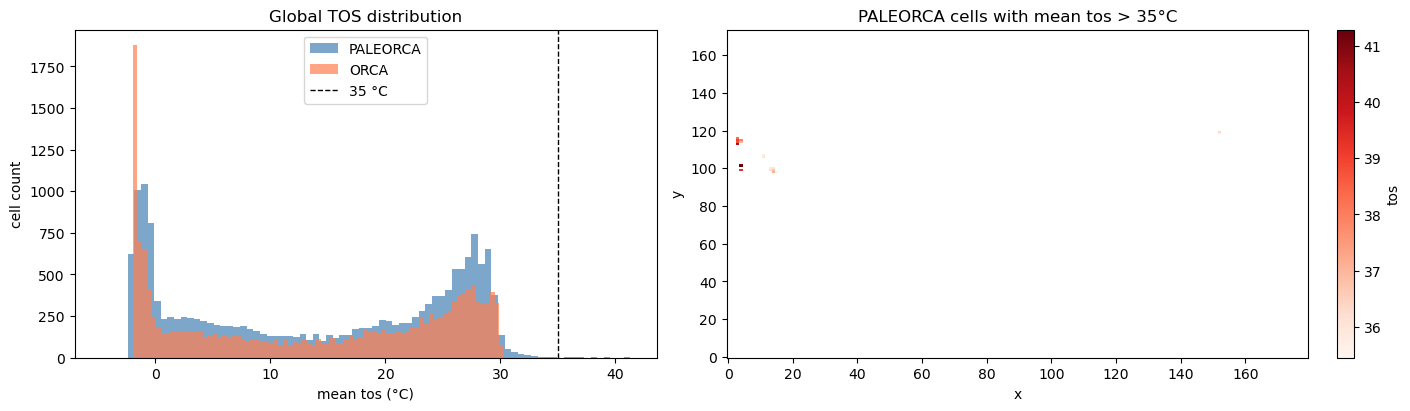

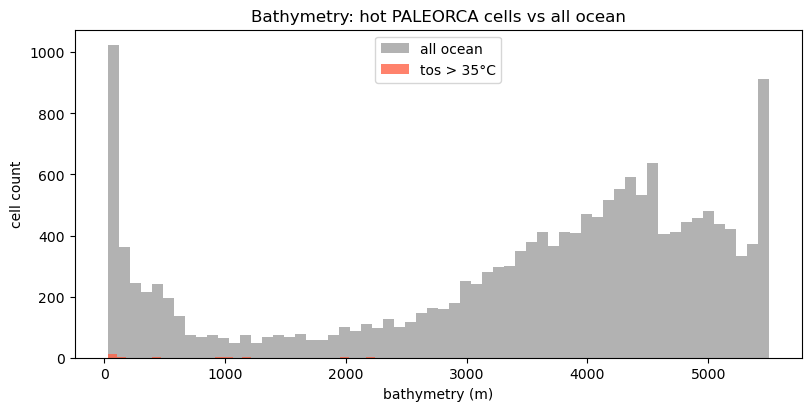

Median bathymetry — hot cells: 64.0 m  |  all ocean: 3950.9 m


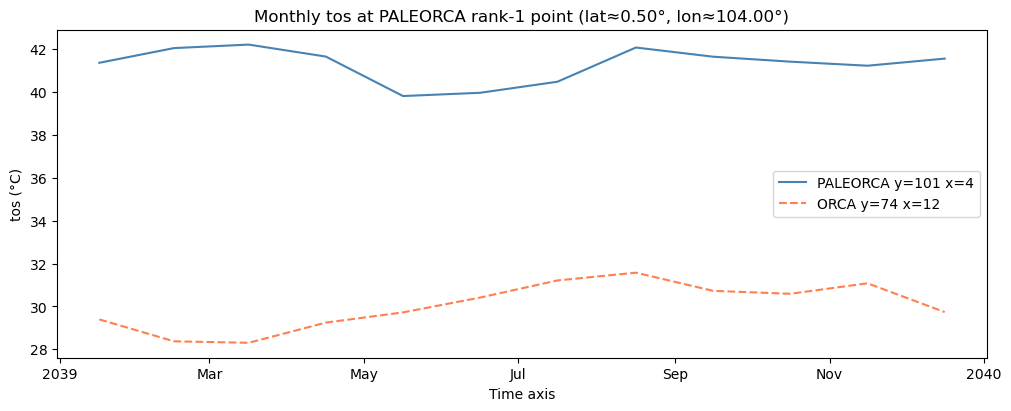


ORCA nearest point: lat=0.501, lon=104.000, bathymetry=30.0 m
(bathymetry=0 → land in ORCA; >0 → ocean)

HYPOTHESIS SUMMARY
──────────────────
• PALEORCA has a distinct cluster of cells with mean tos > 35°C absent in ORCA.
• These cells have very shallow bathymetry (~30 m), typical of marginal
  shelf or enclosed seas in the Eocene palaeogeography.
• In the present-day ORCA grid the same geographic coordinates are likely land
  (bathymetry=0), which is why ORCA has no equivalent hot cells.
• The seasonal cycle plot confirms whether the excess heat is year-round
  (palaeogeographic difference) or seasonal (atmospheric forcing).



In [38]:
# --- Diagnostics: why is PALEORCA tos higher than ORCA? ---

var = 'tos'
pale_native = paleorca_last_native
orca_native  = orca_last_native

pale_mean_native = pale_native[var].mean(dim='time', skipna=True).compute()
orca_mean_native  = orca_native[var].mean(dim='time', skipna=True).compute()

# ── 1. Global TOS histograms ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

p_vals = pale_mean_native.values.ravel()
o_vals = orca_mean_native.values.ravel()
p_vals = p_vals[np.isfinite(p_vals)]
o_vals = o_vals[np.isfinite(o_vals)]

axes[0].hist(p_vals, bins=80, color='steelblue', alpha=0.7, label='PALEORCA')
axes[0].hist(o_vals, bins=80, color='coral',    alpha=0.7, label='ORCA')
axes[0].axvline(35, color='k', linestyle='--', lw=1, label='35 °C')
axes[0].set_xlabel('mean tos (°C)'); axes[0].set_ylabel('cell count')
axes[0].set_title('Global TOS distribution'); axes[0].legend()

n_hot_pale = int((pale_mean_native > 35).values.sum())
n_hot_orca  = int((orca_mean_native  > 35).values.sum())
print(f'PALEORCA cells > 35°C: {n_hot_pale}')
print(f'ORCA    cells > 35°C: {n_hot_orca}')

# ── 2. Where are the hot PALEORCA cells? ────────────────────────────────────
hot_mask = pale_mean_native.where(pale_mean_native > 35)
hot_mask.plot(ax=axes[1], cmap='Reds', add_colorbar=True)
axes[1].set_title('PALEORCA cells with mean tos > 35°C')
plt.show()

# ── 3. Bathymetry at hot cells vs all ocean cells ───────────────────────────
ocean_mask_pale = (paleorca_bathy > 0).compute()
bathy_hot  = paleorca_bathy.where((pale_mean_native > 35) & ocean_mask_pale).values.ravel()
bathy_all  = paleorca_bathy.where(ocean_mask_pale).values.ravel()
bathy_hot  = bathy_hot[np.isfinite(bathy_hot)]
bathy_all  = bathy_all[np.isfinite(bathy_all)]

fig2, ax2 = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax2.hist(bathy_all, bins=60, color='grey',   alpha=0.6, label='all ocean')
ax2.hist(bathy_hot, bins=30, color='tomato', alpha=0.8, label='tos > 35°C')
ax2.set_xlabel('bathymetry (m)'); ax2.set_ylabel('cell count')
ax2.set_title('Bathymetry: hot PALEORCA cells vs all ocean')
ax2.legend()
plt.show()
print(f'Median bathymetry — hot cells: {np.median(bathy_hot):.1f} m  |  all ocean: {np.median(bathy_all):.1f} m')

# ── 4. Seasonal cycle at the rank-1 hot point ───────────────────────────────
top1  = paleorca_top_tos.iloc[0]
y_idx = int(top1['y'])
x_idx = int(top1['x'])
pale_lat = float(top1['lat'])
pale_lon = float(top1['lon'])

pale_ts_hot = pale_native[var].isel(y=y_idx, x=x_idx).compute()

# Nearest-neighbour lookup on 2D ORCA grid
orca_nav_lat = orca_native['nav_lat'].values
orca_nav_lon = orca_native['nav_lon'].values
dist2 = (orca_nav_lat - pale_lat) ** 2 + (orca_nav_lon - pale_lon) ** 2
nearest_ij = np.unravel_index(np.argmin(dist2), dist2.shape)
orca_ts_hot = orca_native[var].isel(y=nearest_ij[0], x=nearest_ij[1]).compute()

fig3, ax3 = plt.subplots(figsize=(10, 4), constrained_layout=True)
pale_ts_hot.plot(ax=ax3, label=f'PALEORCA y={y_idx} x={x_idx}', color='steelblue')
orca_ts_hot.plot(ax=ax3, label=f'ORCA y={nearest_ij[0]} x={nearest_ij[1]}', color='coral', linestyle='--')
ax3.set_title(f'Monthly tos at PALEORCA rank-1 point (lat≈{pale_lat:.2f}°, lon≈{pale_lon:.2f}°)')
ax3.set_ylabel('tos (°C)'); ax3.legend()
plt.show()

# ── 5. Are hot cells in ORCA a wet or dry point? ─────────────────────────────
orca_nav_lat_hot = float(orca_nav_lat[nearest_ij])
orca_nav_lon_hot = float(orca_nav_lon[nearest_ij])
orca_bathy_hot   = float(orca_bathy.isel(y=nearest_ij[0], x=nearest_ij[1]).values)
print(f'\nORCA nearest point: lat={orca_nav_lat_hot:.3f}, lon={orca_nav_lon_hot:.3f}, bathymetry={orca_bathy_hot:.1f} m')
print('(bathymetry=0 → land in ORCA; >0 → ocean)')

print("""
HYPOTHESIS SUMMARY
──────────────────
• PALEORCA has a distinct cluster of cells with mean tos > 35°C absent in ORCA.
• These cells have very shallow bathymetry (~30 m), typical of marginal
  shelf or enclosed seas in the Eocene palaeogeography.
• In the present-day ORCA grid the same geographic coordinates are likely land
  (bathymetry=0), which is why ORCA has no equivalent hot cells.
• The seasonal cycle plot confirms whether the excess heat is year-round
  (palaeogeographic difference) or seasonal (atmospheric forcing).
""")

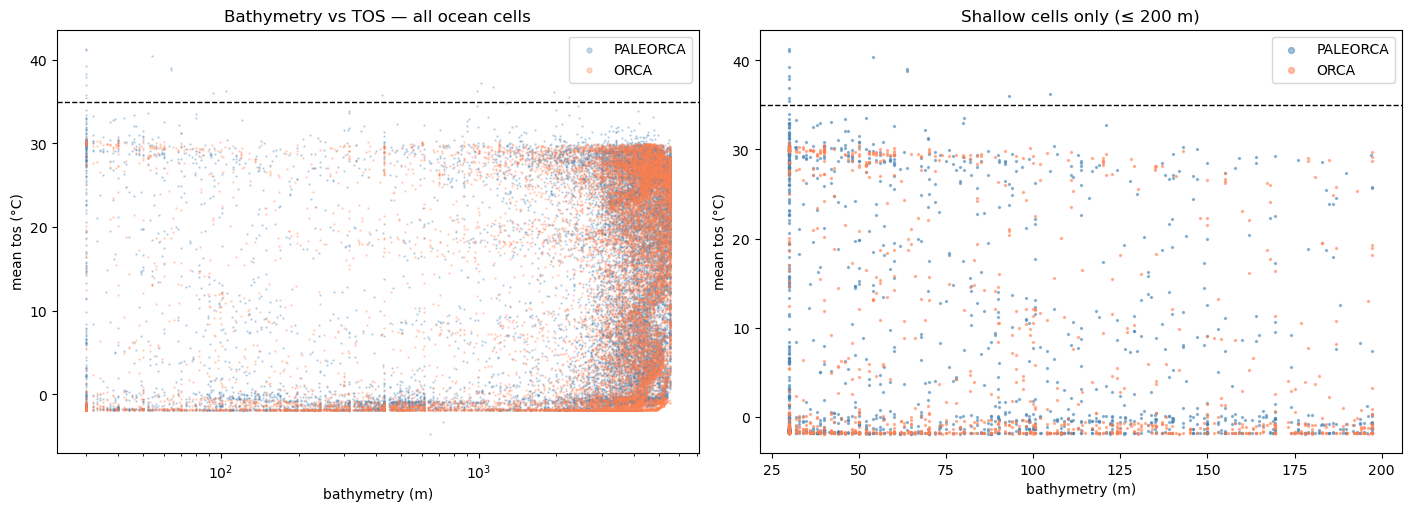

Connectivity analysis for PALEORCA hot cells (tos > 35°C):
    y     x     tos   bathy  wet_N  wet_S  wet_E  wet_W  total_wet_neighbors
   98    14   37.16  1019.7      0      1      1      0                    2
   98    15   35.57  2244.8      0      1      1      1                    3
   99     4   39.28    30.0      0      0      1      0                    1
   99    13   36.26   105.0      0      1      1      0                    2
   99    14   36.76  1138.7      1      1      1      1                    4
  100    13   35.83   421.8      1      0      1      0                    2
  100    14   36.08  1965.7      1      0      1      1                    3
  101     4   41.29    30.0      0      1      1      0                    2
  102     4   41.11    30.0      1      0      1      0                    2
  106    11   36.00    93.0      0      1      1      0                    2
  107    11   35.77    30.0      1      0      1      0                    2
  113     3   40.

/lus/h2resw01/scratch/ccpd/ipykernel_2339037/295129647.py:99: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(pale_nav_lon, pale_nav_lat, tos_reg_p, cmap='hot_r', vmin=20, vmax=42)
/lus/h2resw01/scratch/ccpd/ipykernel_2339037/295129647.py:104: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(orca_nav_lon2, orca_nav_lat2, tos_reg_o, cmap='hot_r', vmin=20, vmax=42)
/lus/h2resw01/scratch/ccpd/ipykernel_2339037/295129647.py:109: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decr

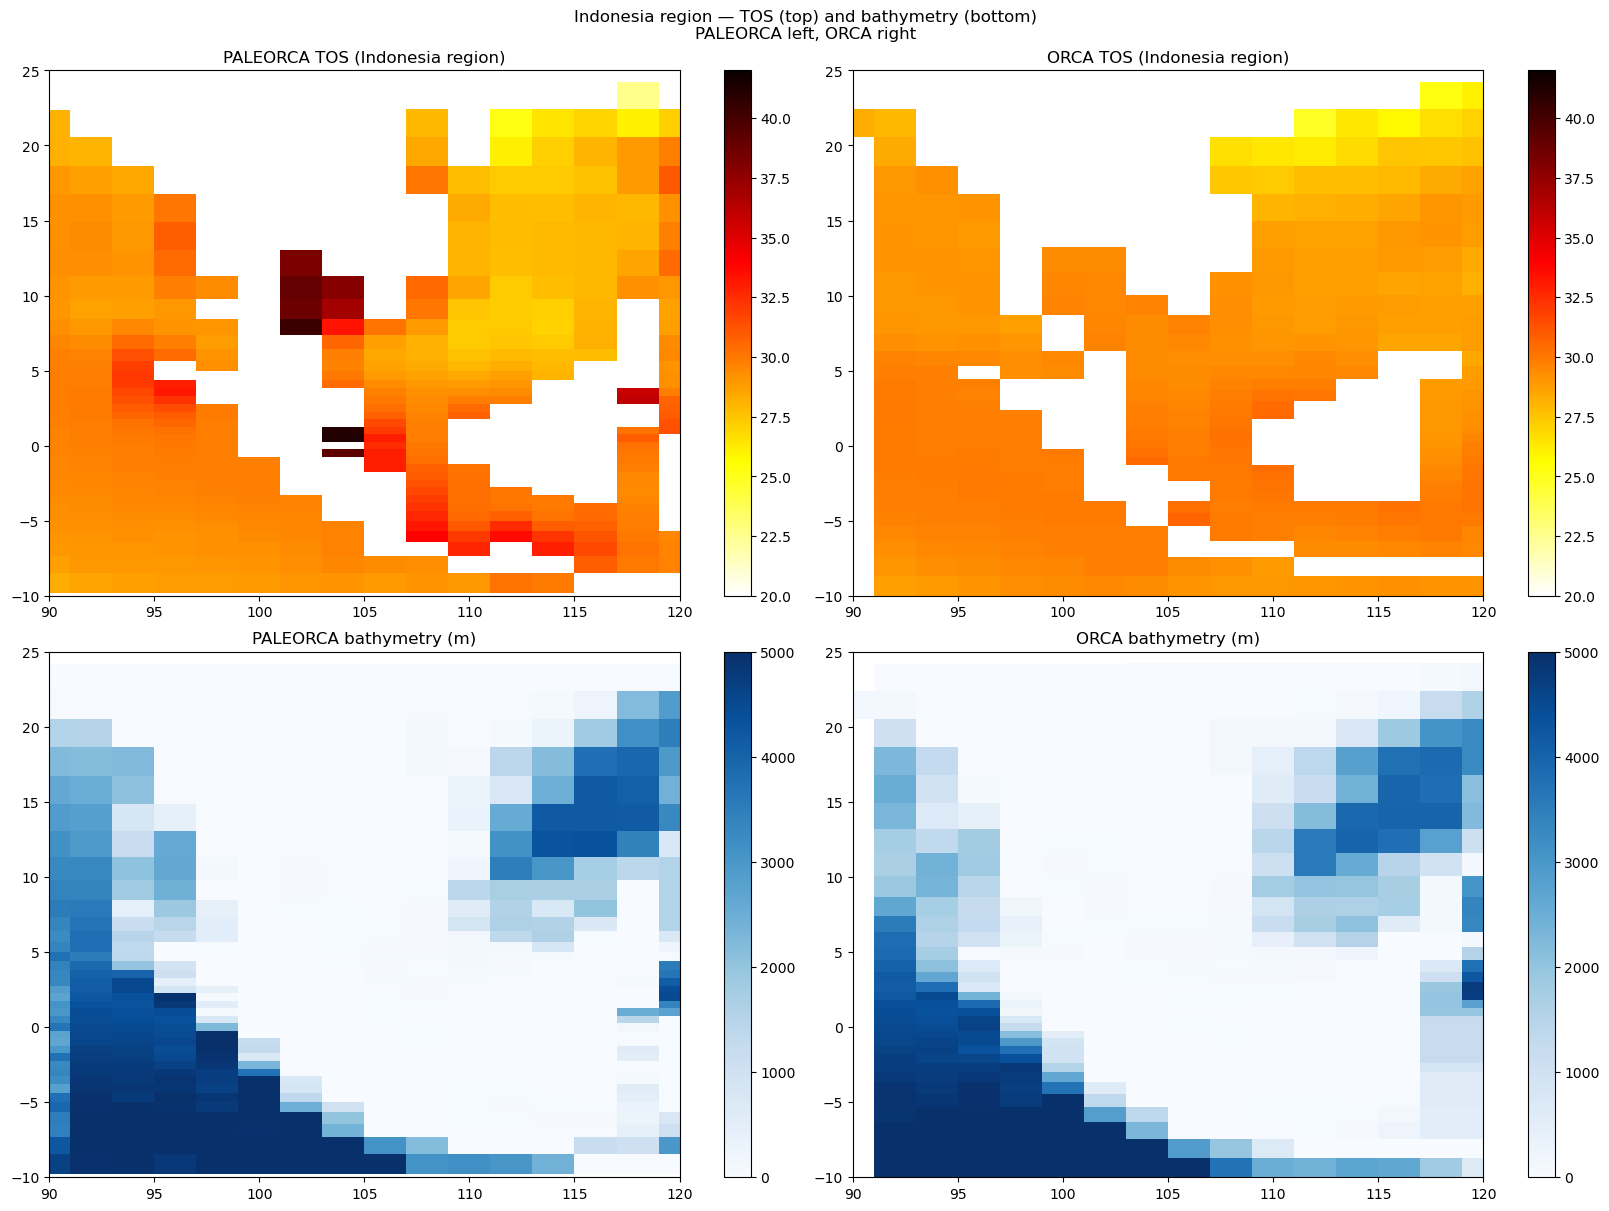

In [39]:
# --- Deeper diagnostics: connectivity & regional comparison ---

var = 'tos'

# ── 1. Scatter: bathymetry vs mean TOS (all ocean cells) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

bathy_p = paleorca_bathy.values.ravel()
tos_p   = pale_mean_native.values.ravel()
mask_p  = np.isfinite(bathy_p) & (bathy_p > 0) & np.isfinite(tos_p)

bathy_o = orca_bathy.values.ravel()
orca_nav_lat_2d = orca_native['nav_lat'].values
tos_o   = orca_mean_native.values.ravel()
mask_o  = np.isfinite(bathy_o) & (bathy_o > 0) & np.isfinite(tos_o)

axes[0].scatter(bathy_p[mask_p], tos_p[mask_p], s=0.5, alpha=0.3, c='steelblue', label='PALEORCA')
axes[0].scatter(bathy_o[mask_o], tos_o[mask_o], s=0.5, alpha=0.3, c='coral',     label='ORCA')
axes[0].axhline(35, color='k', linestyle='--', lw=1)
axes[0].set_xscale('log'); axes[0].set_xlabel('bathymetry (m)'); axes[0].set_ylabel('mean tos (°C)')
axes[0].set_title('Bathymetry vs TOS — all ocean cells'); axes[0].legend(markerscale=5)

# zoom on very shallow cells (bathy <= 200 m)
shallow_p = mask_p & (bathy_p <= 200)
shallow_o = mask_o & (bathy_o <= 200)
axes[1].scatter(bathy_p[shallow_p], tos_p[shallow_p], s=2, alpha=0.5, c='steelblue', label='PALEORCA')
axes[1].scatter(bathy_o[shallow_o], tos_o[shallow_o], s=2, alpha=0.5, c='coral',     label='ORCA')
axes[1].axhline(35, color='k', linestyle='--', lw=1)
axes[1].set_xlabel('bathymetry (m)'); axes[1].set_ylabel('mean tos (°C)')
axes[1].set_title('Shallow cells only (≤ 200 m)'); axes[1].legend(markerscale=3)
plt.show()

# ── 2. Wet-neighbor connectivity of hot PALEORCA cells ───────────────────────
bathy_2d_p = paleorca_bathy.values  # shape (y, x)
tos_2d_p   = pale_mean_native.values

print("Connectivity analysis for PALEORCA hot cells (tos > 35°C):")
print(f"{'y':>5} {'x':>5} {'tos':>7} {'bathy':>7} {'wet_N':>6} {'wet_S':>6} {'wet_E':>6} {'wet_W':>6} {'total_wet_neighbors':>20}")

hot_ys, hot_xs = np.where((tos_2d_p > 35) & (bathy_2d_p > 0))
for y, x in zip(hot_ys, hot_xs):
    ny, nx = bathy_2d_p.shape
    n_n = int(bathy_2d_p[y-1, x] > 0)  if y > 0    else 0
    n_s = int(bathy_2d_p[y+1, x] > 0)  if y < ny-1 else 0
    n_e = int(bathy_2d_p[y, x+1] > 0)  if x < nx-1 else 0
    n_w = int(bathy_2d_p[y, x-1] > 0)  if x > 0    else 0
    total = n_n + n_s + n_e + n_w
    print(f"{y:>5} {x:>5} {tos_2d_p[y,x]:>7.2f} {bathy_2d_p[y,x]:>7.1f} {n_n:>6} {n_s:>6} {n_e:>6} {n_w:>6} {total:>20}")

# Same for a random sample of ORCA shallow cells (bathy=30 m) for comparison
print("\nConnectivity of ORCA cells with bathy≈30m and tos>28°C (sample):")
bathy_2d_o = orca_bathy.values
tos_2d_o   = orca_mean_native.values
hot_yo, hot_xo = np.where((bathy_2d_o > 0) & (bathy_2d_o <= 40) & (tos_2d_o > 28))
print(f"{'y':>5} {'x':>5} {'tos':>7} {'bathy':>7} {'total_wet_neighbors':>20}")
for y, x in zip(hot_yo[:15], hot_xo[:15]):
    ny2, nx2 = bathy_2d_o.shape
    n_n = int(bathy_2d_o[y-1, x] > 0) if y > 0    else 0
    n_s = int(bathy_2d_o[y+1, x] > 0) if y < ny2-1 else 0
    n_e = int(bathy_2d_o[y, x+1] > 0) if x < nx2-1 else 0
    n_w = int(bathy_2d_o[y, x-1] > 0) if x > 0    else 0
    print(f"{y:>5} {x:>5} {tos_2d_o[y,x]:>7.2f} {bathy_2d_o[y,x]:>7.1f} {n_n+n_s+n_e+n_w:>20}")

# ── 3. Regional zoom: Indonesia region TOS and bathymetry ─────────────────────
# Extract lat/lon from native grids
pale_nav_lat = pale_native['nav_lat'].values
pale_nav_lon = pale_native['nav_lon'].values

# Create boolean masks for the region of interest (lon 90-120, lat -10-25)
reg_lat = (pale_nav_lat >= -10) & (pale_nav_lat <= 25)
reg_lon = (pale_nav_lon >= 90)  & (pale_nav_lon <= 120)
reg_mask_p = reg_lat & reg_lon & (bathy_2d_p > 0)

orca_nav_lat2 = orca_native['nav_lat'].values
orca_nav_lon2 = orca_native['nav_lon'].values
reg_lat_o = (orca_nav_lat2 >= -10) & (orca_nav_lat2 <= 25)
reg_lon_o = (orca_nav_lon2 >= 90)  & (orca_nav_lon2 <= 120)
reg_mask_o = reg_lat_o & reg_lon_o & (bathy_2d_o > 0)

print(f"\nRegion (90-120°E, -10-25°N):  PALEORCA ocean cells: {reg_mask_p.sum()},  ORCA ocean cells: {reg_mask_o.sum()}")
print(f"  PALEORCA max TOS in region: {tos_2d_p[reg_mask_p].max():.2f} °C")
print(f"  ORCA     max TOS in region: {tos_2d_o[reg_mask_o].max():.2f} °C")
print(f"  PALEORCA cells > 35°C in region: {(tos_2d_p[reg_mask_p] > 35).sum()}")

# Find row/col ranges for the zoom
ys_p, xs_p = np.where(reg_mask_p)
ys_o, xs_o = np.where(reg_mask_o)

fig2, axes2 = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)

# Build masked arrays for the regional slice
tos_reg_p   = np.where(reg_lat & reg_lon, tos_2d_p,   np.nan)
tos_reg_o   = np.where(reg_lat_o & reg_lon_o, tos_2d_o, np.nan)
bathy_reg_p = np.where(reg_lat & reg_lon, bathy_2d_p,   np.nan)
bathy_reg_o = np.where(reg_lat_o & reg_lon_o, bathy_2d_o, np.nan)

# Use pcolormesh on (y, x) native index space — sufficient to see the pattern
ax = axes2[0, 0]
im = ax.pcolormesh(pale_nav_lon, pale_nav_lat, tos_reg_p, cmap='hot_r', vmin=20, vmax=42)
ax.set_xlim(90, 120); ax.set_ylim(-10, 25)
fig2.colorbar(im, ax=ax); ax.set_title('PALEORCA TOS (Indonesia region)')

ax = axes2[0, 1]
im = ax.pcolormesh(orca_nav_lon2, orca_nav_lat2, tos_reg_o, cmap='hot_r', vmin=20, vmax=42)
ax.set_xlim(90, 120); ax.set_ylim(-10, 25)
fig2.colorbar(im, ax=ax); ax.set_title('ORCA TOS (Indonesia region)')

ax = axes2[1, 0]
im = ax.pcolormesh(pale_nav_lon, pale_nav_lat, bathy_reg_p, cmap='Blues', vmin=0, vmax=5000)
ax.set_xlim(90, 120); ax.set_ylim(-10, 25)
fig2.colorbar(im, ax=ax); ax.set_title('PALEORCA bathymetry (m)')

ax = axes2[1, 1]
im = ax.pcolormesh(orca_nav_lon2, orca_nav_lat2, bathy_reg_o, cmap='Blues', vmin=0, vmax=5000)
ax.set_xlim(90, 120); ax.set_ylim(-10, 25)
fig2.colorbar(im, ax=ax); ax.set_title('ORCA bathymetry (m)')

plt.suptitle('Indonesia region — TOS (top) and bathymetry (bottom)\nPALEORCA left, ORCA right', fontsize=12)
plt.show()

/lus/h2resw01/scratch/ccpd/ipykernel_2339037/1952997961.py:34: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im0 = axes[0].pcolormesh(pale_nav_lon, pale_nav_lat, np.where(rmask_p, tos_2d_p, np.nan),
/lus/h2resw01/scratch/ccpd/ipykernel_2339037/1952997961.py:39: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im1 = axes[1].pcolormesh(orca_nav_lon2, orca_nav_lat2, np.where(rmask_o, tos_2d_o, np.nan),


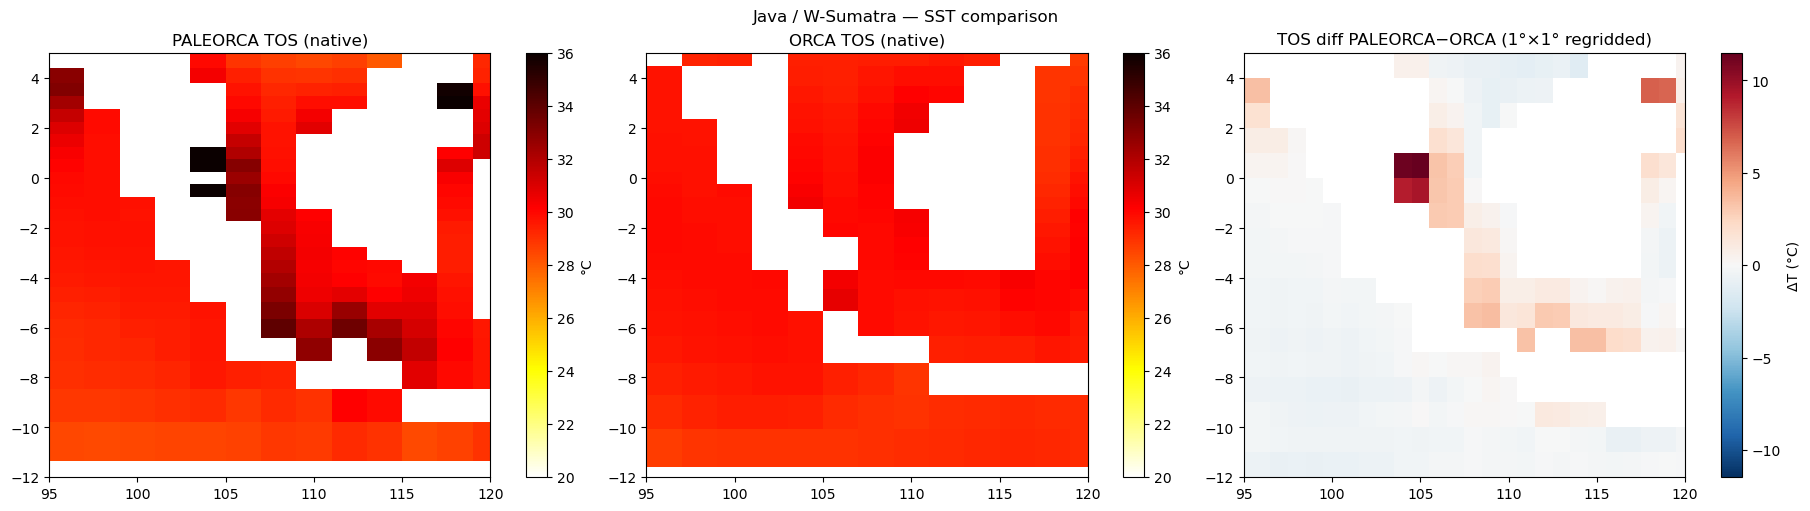

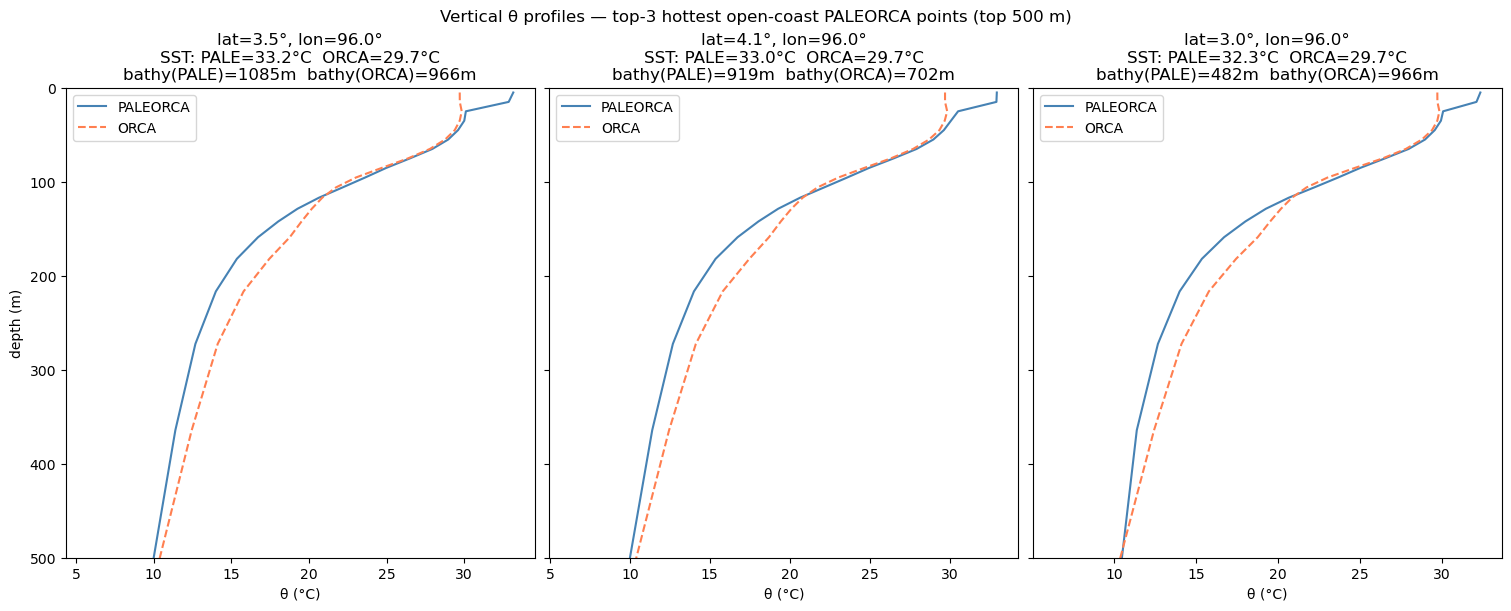

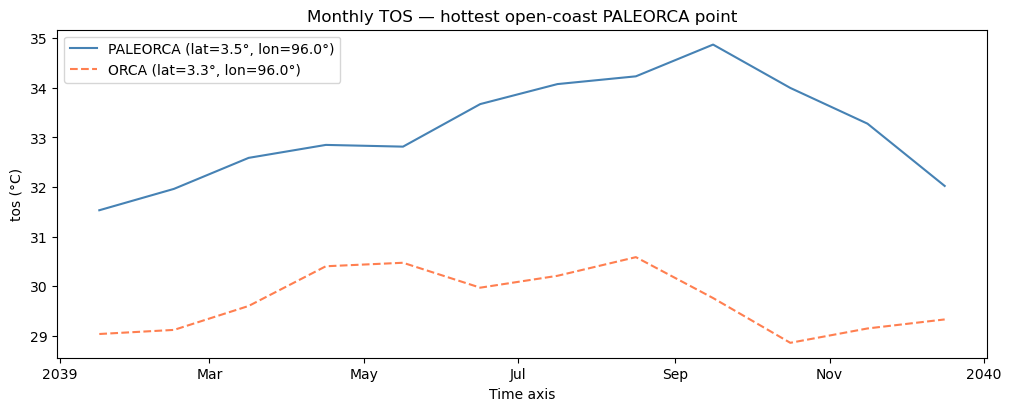

Region (95-120°E, -12-5°N):
  PALEORCA — mean: 30.30°C,  max: 41.29°C
  ORCA     — mean: 29.68°C,  max: 30.72°C


In [41]:
# --- Java / W-Sumatra region: upwelling signature investigation ---

java_lon = (95, 120)
java_lat = (-12, 5)

def region_mask(nav_lat, nav_lon, lat_range, lon_range):
    return (
        (nav_lat >= lat_range[0]) & (nav_lat <= lat_range[1]) &
        (nav_lon >= lon_range[0]) & (nav_lon <= lon_range[1])
    )

pale_nav_lat = pale_native['nav_lat'].values
pale_nav_lon = pale_native['nav_lon'].values
orca_nav_lat2 = orca_native['nav_lat'].values
orca_nav_lon2 = orca_native['nav_lon'].values

rmask_p = region_mask(pale_nav_lat, pale_nav_lon, java_lat, java_lon)
rmask_o = region_mask(orca_nav_lat2, orca_nav_lon2, java_lat, java_lon)

tos_2d_p = pale_mean_native.values
tos_2d_o = orca_mean_native.values

# ── 1. SST maps + difference on common regridded grid ───────────────────────
pale_tos_r = paleorca_last['tos'].mean(dim='time').values
orca_tos_r  = orca_last['tos'].mean(dim='time').values
lats_r = paleorca_last['lat'].values
lons_r = paleorca_last['lon'].values
lon2d_r, lat2d_r = np.meshgrid(lons_r, lats_r)
rmask_r = region_mask(lat2d_r, lon2d_r, java_lat, java_lon)
diff_r  = pale_tos_r - orca_tos_r

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

im0 = axes[0].pcolormesh(pale_nav_lon, pale_nav_lat, np.where(rmask_p, tos_2d_p, np.nan),
                          cmap='hot_r', vmin=20, vmax=36)
axes[0].set_xlim(*java_lon); axes[0].set_ylim(*java_lat)
axes[0].set_title('PALEORCA TOS (native)'); fig.colorbar(im0, ax=axes[0], label='°C')

im1 = axes[1].pcolormesh(orca_nav_lon2, orca_nav_lat2, np.where(rmask_o, tos_2d_o, np.nan),
                          cmap='hot_r', vmin=20, vmax=36)
axes[1].set_xlim(*java_lon); axes[1].set_ylim(*java_lat)
axes[1].set_title('ORCA TOS (native)'); fig.colorbar(im1, ax=axes[1], label='°C')

absmax = float(np.nanmax(np.abs(np.where(rmask_r, diff_r, np.nan))))
im2 = axes[2].pcolormesh(lon2d_r, lat2d_r, np.where(rmask_r, diff_r, np.nan),
                          cmap='RdBu_r', vmin=-absmax, vmax=absmax)
axes[2].set_xlim(*java_lon); axes[2].set_ylim(*java_lat)
axes[2].set_title('TOS diff PALEORCA−ORCA (1°×1° regridded)'); fig.colorbar(im2, ax=axes[2], label='ΔT (°C)')

plt.suptitle('Java / W-Sumatra — SST comparison', fontsize=12)
plt.show()

# ── 2. Vertical temperature profiles at the 3 hottest open-coast points ──────
thetao_p = pale_native['thetao'].mean(dim='time').compute()
thetao_o = orca_native['thetao'].mean(dim='time').compute()

zdim = _pick_depth_dim(thetao_p)
depth_coord_v = _pick_depth_coord(thetao_p, zdim).values

# hottest PALEORCA cells in the region with bathy > 100 m (open coast, not enclosed)
hot_open = (tos_2d_p > 28) & rmask_p & (bathy_2d_p > 100)
hot_ys_r, hot_xs_r = np.where(hot_open)
hot_tos_r = tos_2d_p[hot_ys_r, hot_xs_r]
top3_idx = np.argsort(hot_tos_r)[-3:][::-1]

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 6), constrained_layout=True, sharey=True)

for i, idx in enumerate(top3_idx):
    yp, xp = hot_ys_r[idx], hot_xs_r[idx]
    lat_p = pale_nav_lat[yp, xp]
    lon_p = pale_nav_lon[yp, xp]

    prof_p = thetao_p.isel(y=yp, x=xp).values

    dist2 = (orca_nav_lat2 - lat_p)**2 + (orca_nav_lon2 - lon_p)**2
    yo, xo = np.unravel_index(np.argmin(dist2), dist2.shape)
    prof_o = thetao_o.isel(y=yo, x=xo).values

    axes2[i].plot(prof_p, depth_coord_v, color='steelblue', label='PALEORCA')
    axes2[i].plot(prof_o, depth_coord_v, color='coral',     label='ORCA', linestyle='--')
    axes2[i].invert_yaxis()
    axes2[i].set_ylim(500, 0)
    axes2[i].set_xlabel('θ (°C)')
    axes2[i].set_title(
        f'lat={lat_p:.1f}°, lon={lon_p:.1f}°\n'
        f'SST: PALE={tos_2d_p[yp,xp]:.1f}°C  ORCA={tos_2d_o[yo,xo]:.1f}°C\n'
        f'bathy(PALE)={bathy_2d_p[yp,xp]:.0f}m  bathy(ORCA)={orca_bathy.values[yo,xo]:.0f}m'
    )
    axes2[i].legend()

axes2[0].set_ylabel('depth (m)')
plt.suptitle('Vertical θ profiles — top-3 hottest open-coast PALEORCA points (top 500 m)', fontsize=12)
plt.show()

# ── 3. Seasonal cycle at the hottest open-coast point ───────────────────────
yp, xp = hot_ys_r[top3_idx[0]], hot_xs_r[top3_idx[0]]
lat_p   = pale_nav_lat[yp, xp]
lon_p   = pale_nav_lon[yp, xp]
dist2   = (orca_nav_lat2 - lat_p)**2 + (orca_nav_lon2 - lon_p)**2
yo, xo  = np.unravel_index(np.argmin(dist2), dist2.shape)

ts_pale = pale_native['tos'].isel(y=yp, x=xp).compute()
ts_orca = orca_native['tos'].isel(y=yo, x=xo).compute()

fig3, ax3 = plt.subplots(figsize=(10, 4), constrained_layout=True)
ts_pale.plot(ax=ax3, color='steelblue', label=f'PALEORCA (lat={lat_p:.1f}°, lon={lon_p:.1f}°)')
ts_orca.plot(ax=ax3, color='coral',     label=f'ORCA (lat={orca_nav_lat2[yo,xo]:.1f}°, lon={orca_nav_lon2[yo,xo]:.1f}°)', linestyle='--')
ax3.set_title('Monthly TOS — hottest open-coast PALEORCA point'); ax3.set_ylabel('tos (°C)'); ax3.legend()
plt.show()

# ── 4. Statistics ───────────────────────────────────────────────────────────
tos_pale_reg = tos_2d_p[rmask_p & (bathy_2d_p > 0)]
tos_orca_reg = tos_2d_o[rmask_o & (orca_bathy.values > 0)]
print(f"Region ({java_lon[0]}-{java_lon[1]}°E, {java_lat[0]}-{java_lat[1]}°N):")
print(f"  PALEORCA — mean: {np.nanmean(tos_pale_reg):.2f}°C,  max: {np.nanmax(tos_pale_reg):.2f}°C")
print(f"  ORCA     — mean: {np.nanmean(tos_orca_reg):.2f}°C,  max: {np.nanmax(tos_orca_reg):.2f}°C")

temperature difference in the last year

Text(0.5, 0.98, 'thetao: 9-panel comparison at surface, ~100 m, ~300 m (vmin=0, vmax=40)')

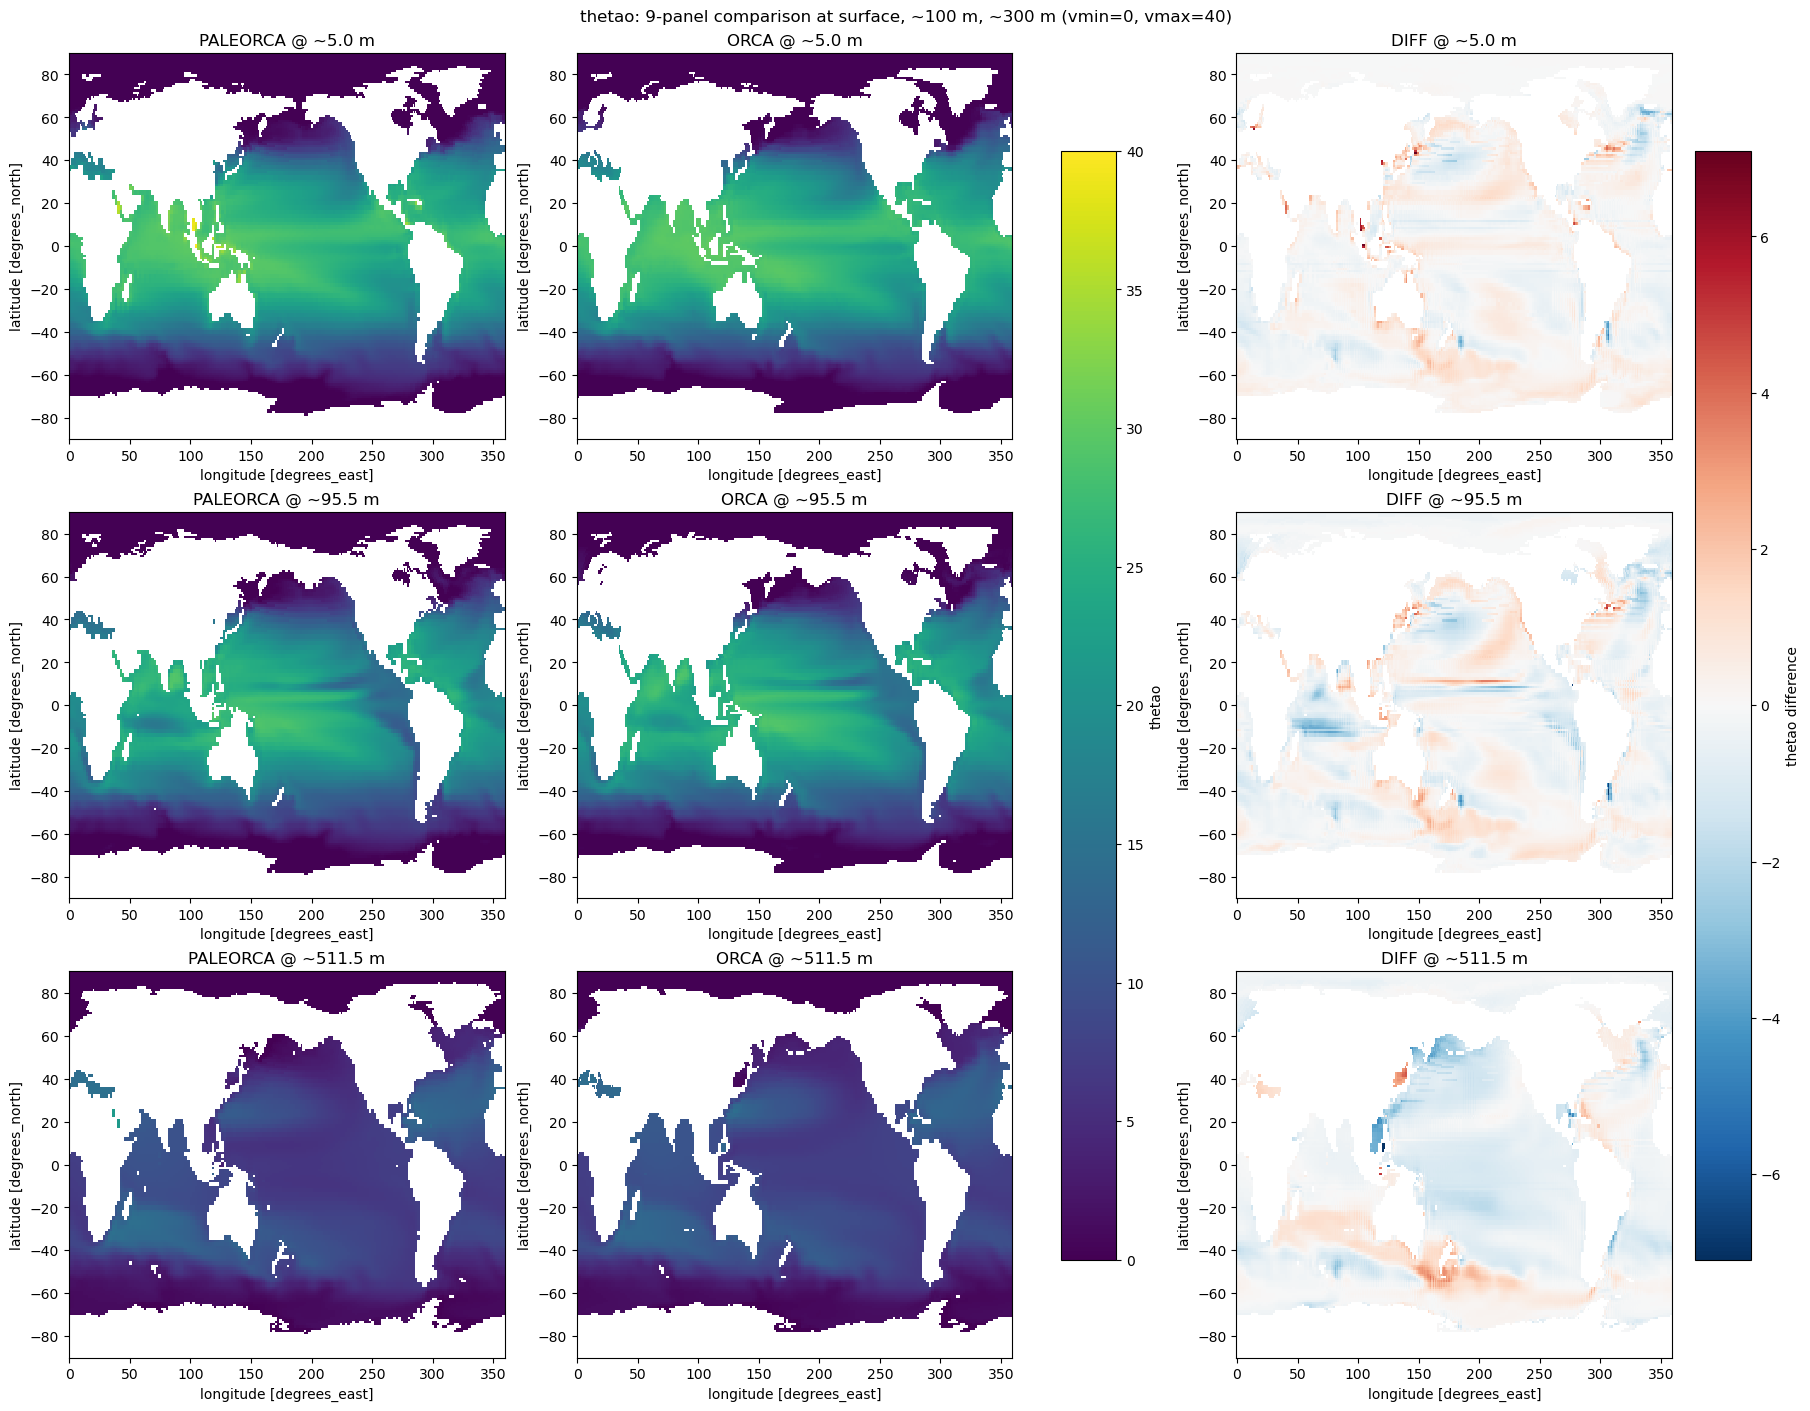

In [24]:
import numpy as np

var = 'thetao'
vmin = 0
vmax = 40

# Time-mean 3D fields
paleorca_t = paleorca_last[var].mean(dim='time')
orca_t = orca_last[var].mean(dim='time')

# 3-panel: use surface level (~0 m) so each panel is 2D map
def _pick_depth_dim(da):
    for cand in ['deptht', 'depth', 'z', 'lev', 'olevel', 'nav_lev']:
        if cand in da.dims:
            return cand
    raise ValueError(f'No vertical dimension found in {da.dims}')


def _pick_depth_coord(da, zdim):
    if zdim in da.coords:
        return da.coords[zdim]
    for cand in ['deptht', 'depth', 'z', 'lev', 'olevel', 'nav_lev']:
        if cand in da.coords and cand in da.dims:
            return da.coords[cand]
    raise ValueError(f'No depth coordinate found for dimension {zdim}')


def _nearest_level_index(depth_coord, target_m):
    return int(np.abs(depth_coord - target_m).argmin())

zdim = _pick_depth_dim(paleorca_t)
depth_coord = _pick_depth_coord(paleorca_t, zdim)

# 9-panel: 3 depths (surface, ~100 m, ~300 m) x (PALEORCA, ORCA, DIFF)
level_targets = [0.0, 100.0, 500.0]
level_indices = [_nearest_level_index(depth_coord, d) for d in level_targets]

fig9, axes9 = plt.subplots(3, 3, figsize=(18, 14), constrained_layout=True)

for r, idx in enumerate(level_indices):
    pale_slice = paleorca_t.isel({zdim: idx})
    orca_slice = orca_t.isel({zdim: idx})
    diff_slice = pale_slice - orca_slice

    im_p = pale_slice.plot(
        ax=axes9[r, 0], vmin=vmin, vmax=vmax, cmap='viridis', add_colorbar=False
    )
    axes9[r, 0].set_title(f'PALEORCA @ ~{float(depth_coord.isel({zdim: idx}).item()):.1f} m')

    im_o = orca_slice.plot(
        ax=axes9[r, 1], vmin=vmin, vmax=vmax, cmap='viridis', add_colorbar=False
    )
    axes9[r, 1].set_title(f'ORCA @ ~{float(depth_coord.isel({zdim: idx}).item()):.1f} m')

    row_diff_abs = float(np.nanmax(np.abs(diff_slice.values)))
    row_diff_abs = max(row_diff_abs, 1e-12)
    im_d = diff_slice.plot(
        ax=axes9[r, 2], vmin=-row_diff_abs, vmax=row_diff_abs, cmap='RdBu_r', add_colorbar=False,
        extend='both'
    )
    axes9[r, 2].set_title(f'DIFF @ ~{float(depth_coord.isel({zdim: idx}).item()):.1f} m')

fig9.colorbar(im_o, ax=axes9[:, :2], label=var, shrink=0.85)
fig9.colorbar(im_d, ax=axes9[:, 2], label=f'{var} difference', shrink=0.85)
fig9.suptitle(f'{var}: 9-panel comparison at surface, ~100 m, ~300 m (vmin={vmin}, vmax={vmax})')

load the areas

In [7]:
paleorca = load_nemo("KA02", last_n_years=None, regrid=False)
orca = load_nemo("KA03", last_n_years=None, regrid=False)

Found 50 files for experiment KA02
Loading following files: ['/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1990-1990.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1991-1991.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1992-1992.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1993-1993.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1994-1994.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1995-1995.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1996-1996.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1997-1997.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1998-1998.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1999-1999.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2000-2000.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2001-2

Loading area file: /lus/h2resw01/scratch/ccpd/ece4/KA02/domain_cfg.nc
Loading area file: /lus/h2resw01/scratch/ccpd/ece4/KA03/domain_cfg.nc


Text(0.5, 1.0, 'Global mean weighted tos difference (KA02, PALEORCA - KA03, ORCA)')

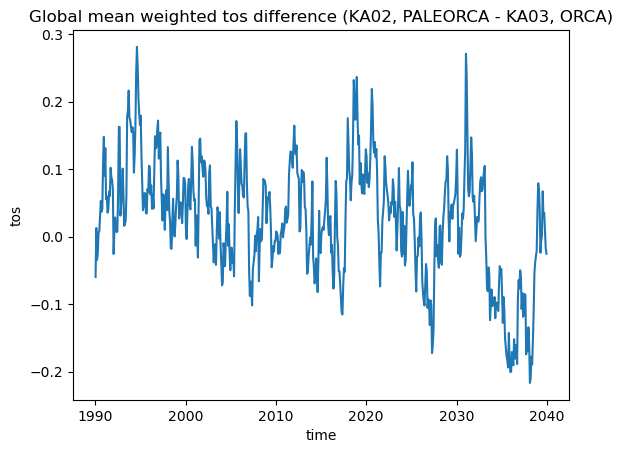

In [8]:
var = 'tos'
paleorca_area = load_area("KA02")
orca_area = load_area("KA03")
paleorca_ts = paleorca['tos'].weighted(paleorca_area).mean(dim=["y", "x"])
orca_ts = orca['tos'].weighted(orca_area).mean(dim=["y", "x"])
(paleorca_ts - orca_ts).plot()
plt.title(f"Global mean weighted {var} difference (KA02, PALEORCA - KA03, ORCA)")

In [6]:
paleorca = load_nemo("KA02", last_n_years=None, regrid=False)
orca = load_nemo("KA03", last_n_years=None, regrid=False, running=True)

Found 50 files for experiment KA02
Loading following files: ['/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1990-1990.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1991-1991.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1992-1992.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1993-1993.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1994-1994.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1995-1995.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1996-1996.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1997-1997.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1998-1998.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_1999-1999.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2000-2000.nc', '/lus/h2resw01/scratch/ccpd/ece4/KA02/output/nemo/KA02_oce_1m_T_2001-2